# Análisis de señales BITalino — Emma y Vivi

Este notebook organiza las mediciones de **2 personas (Emma y Vivi)**, **5 condiciones** y **2 canales medidos simultáneamente** con BITalino.

### Condiciones
1. Basal
2. Abre y cierra
3. Preguntas complejas
4. Música tranquila
5. Música ruidosa

Para cada persona y condición se genera una figura con los **2 canales**, mostrando en cada canal la **señal original y la señal filtrada**.

Además, se generan **5 figuras comparativas Emma vs. Vivi**, una por condición, para observar diferencias entre ambas personas.

> **Solo necesitas modificar la celda de configuración** con los nombres reales de tus archivos y de los canales del BITalino.

In [ ]:
# Instalar dependencias (ejecutar una sola vez si es necesario)
!pip install -q opensignalsreader scipy matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 1.1 MB/s eta 0:00:00


## 1. Configuración

### Esta es la principal celda que debes modificar.

- `CARPETA_DATOS`: carpeta donde están los `.txt`.
- `ARCHIVOS`: nombre de cada archivo de Emma y Vivi para cada condición.
- `CANALES`: nombres de los dos canales registrados en OpenSignals/BITalino.
- `NOMBRES_CANALES`: nombres que aparecerán en las gráficas.

Si tus archivos tienen otros nombres, **solo cambia los textos dentro de `ARCHIVOS`**.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from opensignalsreader import OpenSignalsReader
from scipy.signal import butter, filtfilt, iirnotch

%matplotlib inline

# ============================================================
# CAMBIA SOLO ESTA PARTE
# ============================================================

# Carpeta donde están tus archivos .txt
CARPETA_DATOS = "."
try:
    # Esto solo funciona dentro de Google Colab
    from google.colab import drive
    drive.mount('/content/drive')

    # --------------------------------------------------------------
    CARPETA_DATOS = "/content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG"

    print(f"Google Drive montado. Carpeta de datos configurada en: {CARPETA_DATOS}")

except ImportError:
    print("No se detectó Google Colab. Se usará la carpeta local del notebook (.)")

print("Contenido de la carpeta de datos:")
if os.path.isdir(CARPETA_DATOS):
    print(os.listdir(CARPETA_DATOS))
else:
    print(f"  [!] La carpeta '{CARPETA_DATOS}' todavía no existe o la ruta es incorrecta.")
# Archivos de cada persona y condición
# Reemplaza los nombres por los nombres EXACTOS de tus archivos.
ARCHIVOS = {
    "Emma": {
        "Basal": "basal_emma.txt",
        "Abre y cierra": "abre_cierra_emma.txt",
        "Preguntas complejas": "preguntas_emma.txt",
        "Música tranquila": "musica_tranquila_emma.txt",
        "Música ruidosa": "musica_hard_emma.txt",
    },
    "Vivi": {
        "Basal": "basal_vivi.txt",
        "Abre y cierra": "abre_cierra_vivi.txt",
        "Preguntas complejas": "preguntas_vivi.txt",
        "Música tranquila": "musica_tranquila_vivi.txt",
        "Música ruidosa": "musica_hard_vivi.txt",
    }
}

# ============================================================
# CAMBIA ESTOS NOMBRES POR LOS NOMBRES REALES DE TUS CANALES
# ============================================================

CANALES = [2, 6]

# Nombres que se mostrarán en las gráficas
NOMBRES_CANALES = {
    2: "Canal 2",
    6: "Canal 6",
}

# ============================================================
# PARÁMETROS DEL FILTRO
# ============================================================

# Ajusta estos valores si en tu práctica les indicaron otros.
FREQ_BAJA = 0.5       # Hz
FREQ_ALTA = 40        # Hz
FREQ_NOTCH = 60       # Hz
Q_NOTCH = 30
ORDEN_FILTRO = 4

# Tiempo que se mostrará en las gráficas.
# Usa None para mostrar toda la señal.
TIEMPO_MAX = 15

# Carpeta para guardar automáticamente las figuras
CARPETA_SALIDA = os.path.join(CARPETA_DATOS, "figuras_Emma_Vivi")
os.makedirs(CARPETA_SALIDA, exist_ok=True)

print("Configuración cargada.")
print("Canales:", CANALES)
print("Carpeta de datos:", CARPETA_DATOS)
print("Carpeta de salida:", CARPETA_SALIDA)

Mounted at /content/drive
Google Drive montado. Carpeta de datos configurada en: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG
Contenido de la carpeta de datos:
['basal_emma.txt', 'basal_emma.h5', 'abre_cierra_emma.txt', 'abre_cierra_emma.h5', 'preguntas_emma.txt', 'preguntas_emma.h5', 'musica_tranquila_emma.txt', 'musica_tranquila_emma.h5', 'musica_hard_emma.txt', 'musica_hard_emma.h5', 'basal_vivi.txt', 'basal_vivi.h5', 'abre_cierra_vivi.txt', 'abre_cierra_vivi.h5', 'preguntas_vivi.txt', 'preguntas_vivi.h5', 'musica_tranquila_vivi.txt', 'musica_tranquila_vivi.h5', 'musica_hard_vivi.txt', 'musica_hard_vivi.h5', 'figuras_Emma_Vivi', 'figuras_bitalino', 'analisis_bitalino_EEG1.ipynb', 'Copia_de_analisis_bitalino_ECG(1).ipynb']
Configuración cargada.
Canales: [2, 6]
Carpeta de datos: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG
Carpeta de salida: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/fig

## 2. Carga de las señales

La función siguiente lee cada archivo de OpenSignals y obtiene:
- tiempo (`t`)
- señal convertida (`senal`)
- señal cruda (`senal_cruda`)
- frecuencia de muestreo (`fs`)

No necesitas modificar esta parte.

In [ ]:
def cargar_senal(ruta_archivo, canal):
    """Carga un canal EEG desde el archivo OpenSignals y lo convierte a µV."""

    if not os.path.isfile(ruta_archivo):
        print(f"[!] No se encontró: {ruta_archivo}")
        return None

    try:
        fs = 1000.0

        # Columnas del archivo OpenSignals
        columnas = {
            2: 5,   # A2
            5: 6,   # A5
            6: 7    # A6
        }

        if canal not in columnas:
            print(f"[!] El canal {canal} no está disponible en el archivo.")
            return None

        columna = columnas[canal]

        # Leer ADC crudo
        adc_crudo = np.loadtxt(
            ruta_archivo,
            comments="#",
            delimiter="\t",
            usecols=columna
        )

        adc_crudo = np.asarray(adc_crudo, dtype=float)

        # =====================================
        # CONVERSIÓN DEL ADC A SEÑAL EEG
        # =====================================

        VCC = 3.3
        G_EEG = 40000
        n = 10

        senal_A2_eeg = (
            (((adc_crudo / (2**n)) - 0.5) * VCC)
            / G_EEG
        ) * 1e6

        # Tiempo
        t = np.arange(len(senal_A2_eeg)) / fs

        # La señal ya convertida será la señal que usamos
        senal = senal_A2_eeg

        # Guardamos también una copia para la señal original
        senal_cruda = senal_A2_eeg.copy()

        return t, senal, senal_cruda, fs

    except Exception as e:
        print(f"[!] Error al leer '{ruta_archivo}' con el canal '{canal}': {e}")
        return None

In [ ]:
ruta = os.path.join(CARPETA_DATOS, "basal_emma.txt")

resultado = cargar_senal(ruta, 2)

print("¿Se cargó?", resultado is not None)

if resultado is not None:
    t, senal, senal_cruda, fs = resultado

    print("Frecuencia:", fs)
    print("Número de muestras:", len(senal))
    print("Primeros valores:", senal[:10])

¿Se cargó? True
Frecuencia: 1000.0
Número de muestras: 90450
Primeros valores: [ 36.65771484  40.76660156  40.76660156  40.76660156  40.76660156
  40.76660156  40.76660156   9.99023438 -18.20800781 -41.25      ]


## 3. Filtro

Se aplica un filtro pasa-banda y después un notch para reducir componentes fuera de la banda de interés y la interferencia de red eléctrica.

Si el filtro usado en tu curso es diferente, modifica los parámetros de la celda de configuración.

In [ ]:
def filtrar_senal(senal, fs,
                  low=FREQ_BAJA,
                  high=FREQ_ALTA,
                  notch_freq=FREQ_NOTCH,
                  notch_q=Q_NOTCH,
                  orden=ORDEN_FILTRO):
    """Aplica pasa-banda + notch a una señal."""

    nyq = fs / 2

    if high >= nyq:
        raise ValueError(
            f"FREQ_ALTA={high} Hz debe ser menor que la frecuencia de Nyquist ({nyq:.2f} Hz)."
        )

    # Pasa-banda
    b, a = butter(orden, [low / nyq, high / nyq], btype="band")
    filtrada = filtfilt(b, a, senal)

    # Notch solo si la frecuencia de red está dentro del rango permitido
    if notch_freq < nyq:
        b_notch, a_notch = iirnotch(notch_freq / nyq, notch_q)
        filtrada = filtfilt(b_notch, a_notch, filtrada)

    return filtrada

## 4. Gráficas individuales

Cada figura corresponde a **una persona + una condición**.

Dentro de la figura aparecen los dos canales: **Canal 1 y Canal 2**. En cada canal se superponen:
- señal original
- señal filtrada

Por lo tanto, se generan **10 figuras**: 5 para Emma y 5 para Vivi.

In [ ]:
def graficar_persona_condicion(persona, condicion, nombre_archivo):
    """Genera una figura con los 2 canales de una persona y condición."""

    ruta_archivo = os.path.join(CARPETA_DATOS, nombre_archivo)

    if not os.path.isfile(ruta_archivo):
        print(f"[!] No se encontró: {ruta_archivo}")
        return None

    fig, axes = plt.subplots(
        len(CANALES),
        1,
        figsize=(12, 7),
        sharex=True
    )

    # Si solo hay un canal, convertir axes en lista
    if len(CANALES) == 1:
        axes = [axes]

    for ax, canal in zip(axes, CANALES):

        # =========================
        # 1. Cargar señal
        # =========================
        resultado = cargar_senal(ruta_archivo, canal)

        if resultado is None:
            continue

        t, senal, senal_cruda, fs = resultado

        # =========================
        # 2. Filtrar señal
        # =========================
        filtrada = filtrar_senal(senal, fs)

        # =========================
        # 3. Limitar a 15 segundos
        # =========================
        n_muestras = int(TIEMPO_MAX * fs)

        t_grafica = t[:n_muestras]
        original_grafica = senal_cruda[:n_muestras]
        filtrada_grafica = filtrada[:n_muestras]

        # =========================
        # 4. Dibujar señal original
        # =========================
        # Mostramos 1 de cada 10 puntos
        # solamente para que la gráfica no se vea como un bloque azul
        paso = 10

        ax.plot(
            t_grafica[::paso],
            original_grafica[::paso],
            label="Original",
            linewidth=0.8,
            alpha=0.5
        )

        # =========================
        # 5. Dibujar señal filtrada
        # =========================
        ax.plot(
            t_grafica,
            filtrada_grafica,
            label="Filtrada",
            linewidth=1
        )

        # =========================
        # 6. Configuración del gráfico
        # =========================
        ax.set_title(NOMBRES_CANALES[canal])
        ax.set_ylabel("Amplitud")
        ax.grid(True, alpha=0.3)
        ax.legend()

    axes[-1].set_xlabel("Tiempo (s)")

    fig.suptitle(
        f"{persona} - {condicion}",
        fontsize=14
    )

    fig.tight_layout()

    # =========================
    # 7. Guardar figura
    # =========================
    nombre_salida = (
        f"{persona}_{condicion.replace(' ', '_')}.png"
    )

    ruta_salida = os.path.join(
        CARPETA_SALIDA,
        nombre_salida
    )

    fig.savefig(
        ruta_salida,
        dpi=150,
        bbox_inches="tight"
    )

    print(f"[✓] Guardado: {ruta_salida}")

    return fig

In [ ]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'drive', 'sample_data']


[✓] Guardado: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_Emma_Vivi/Emma_Basal.png


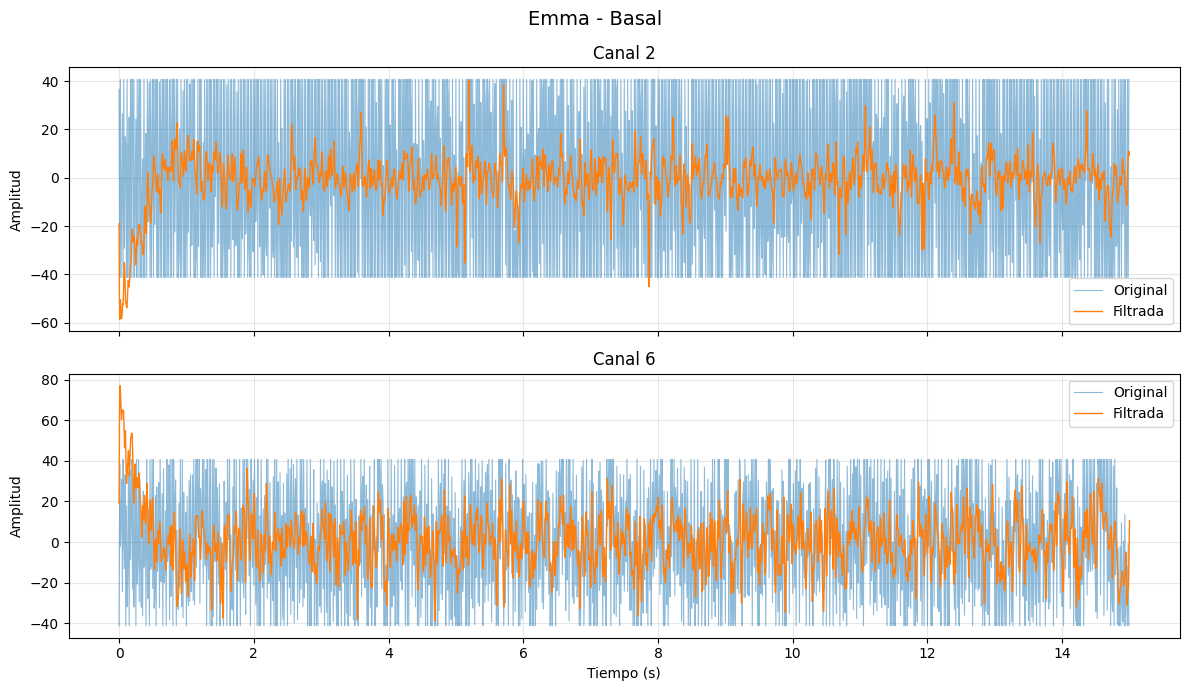

[✓] Guardado: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_Emma_Vivi/Emma_Abre_y_cierra.png


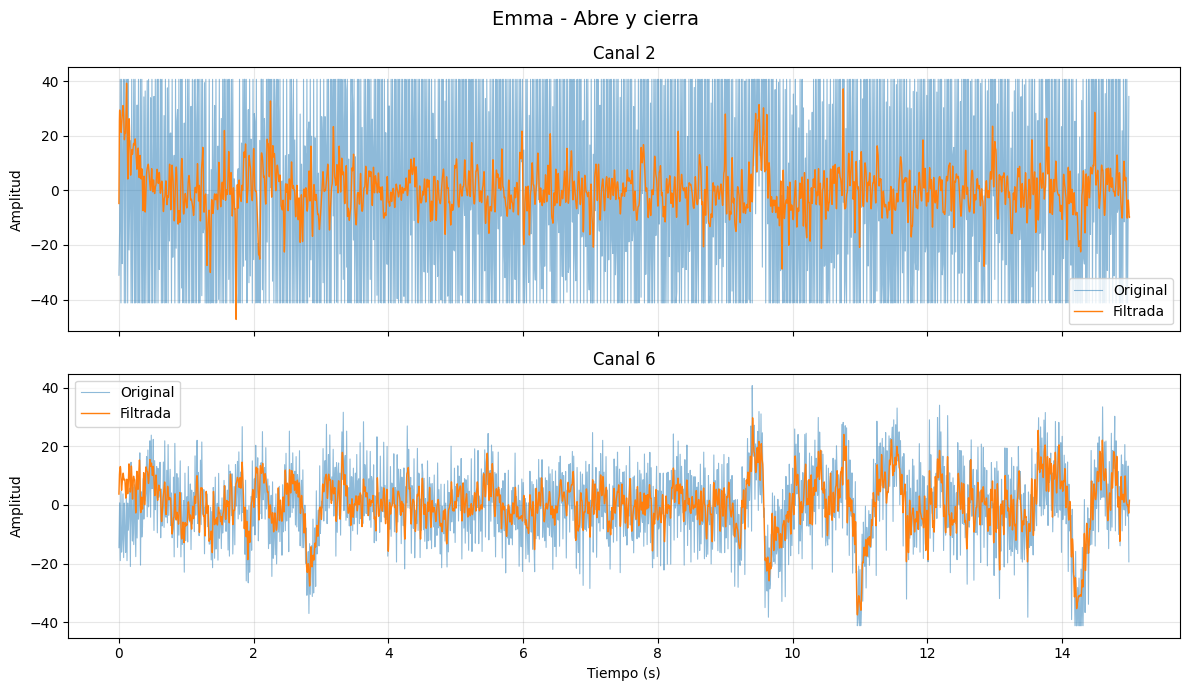

[✓] Guardado: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_Emma_Vivi/Emma_Preguntas_complejas.png


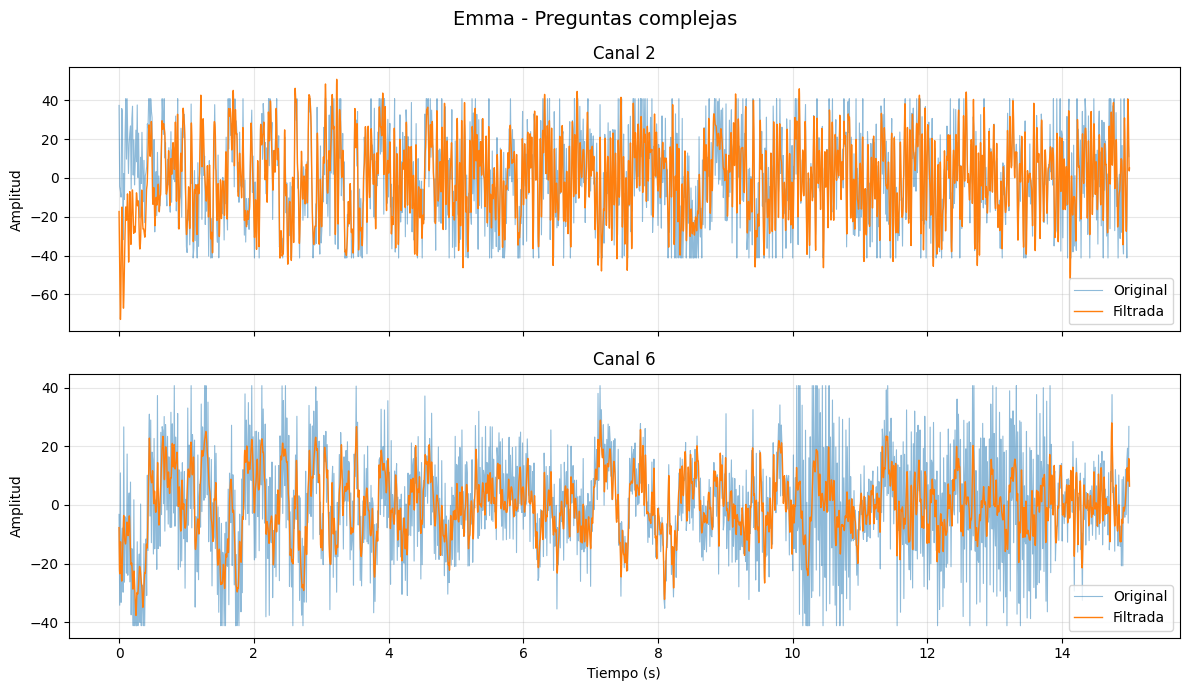

[✓] Guardado: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_Emma_Vivi/Emma_Música_tranquila.png


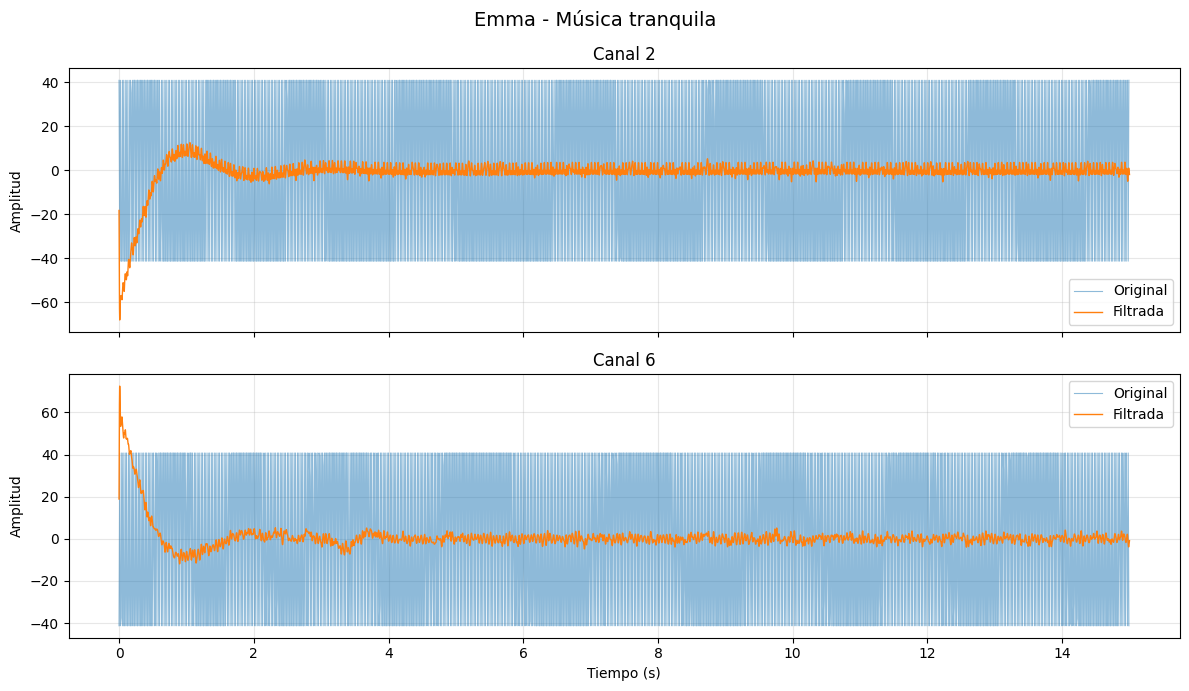

[✓] Guardado: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_Emma_Vivi/Emma_Música_ruidosa.png


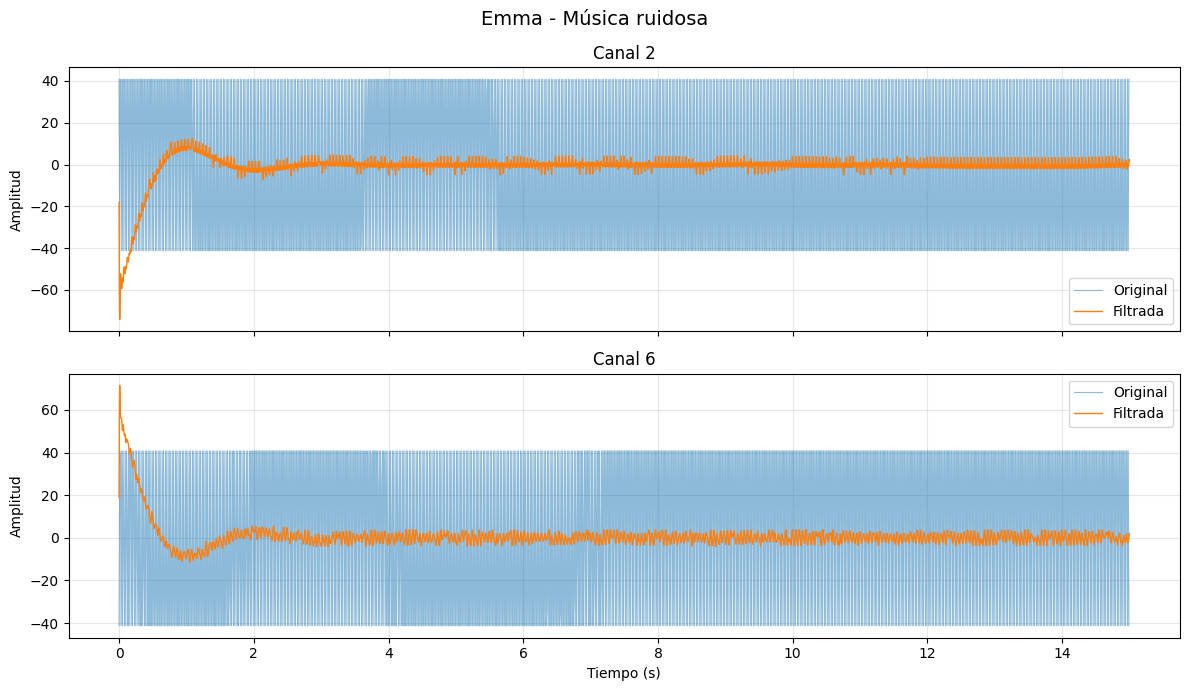

[✓] Guardado: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_Emma_Vivi/Vivi_Basal.png


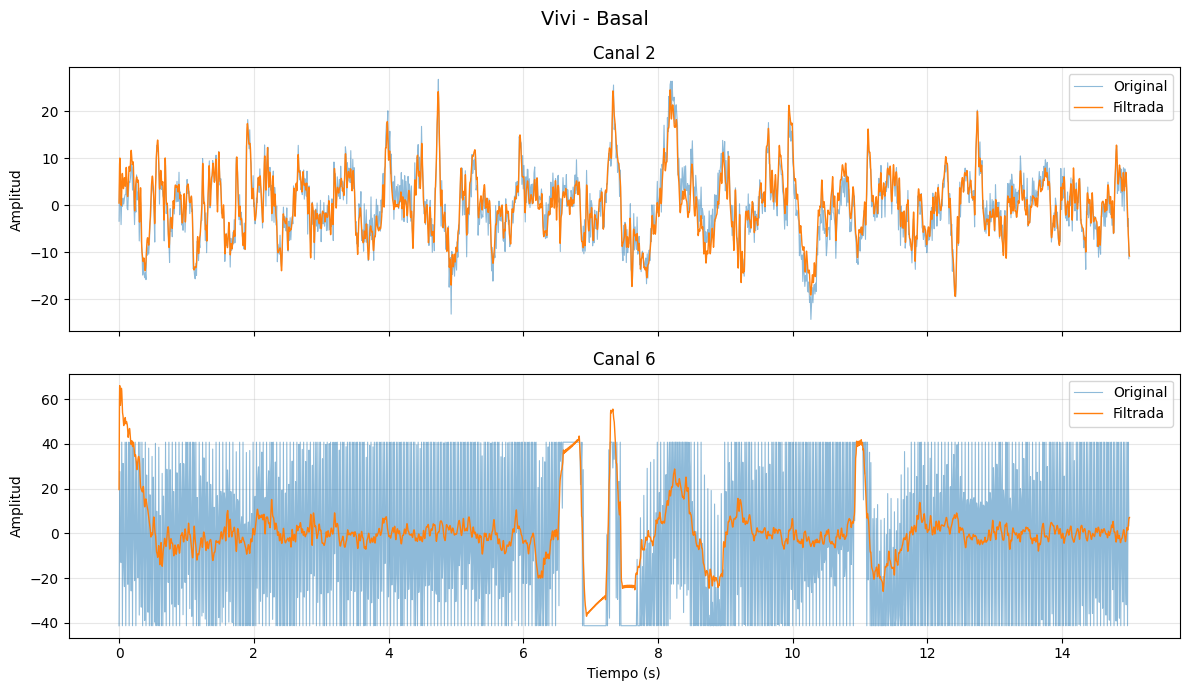

[✓] Guardado: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_Emma_Vivi/Vivi_Abre_y_cierra.png


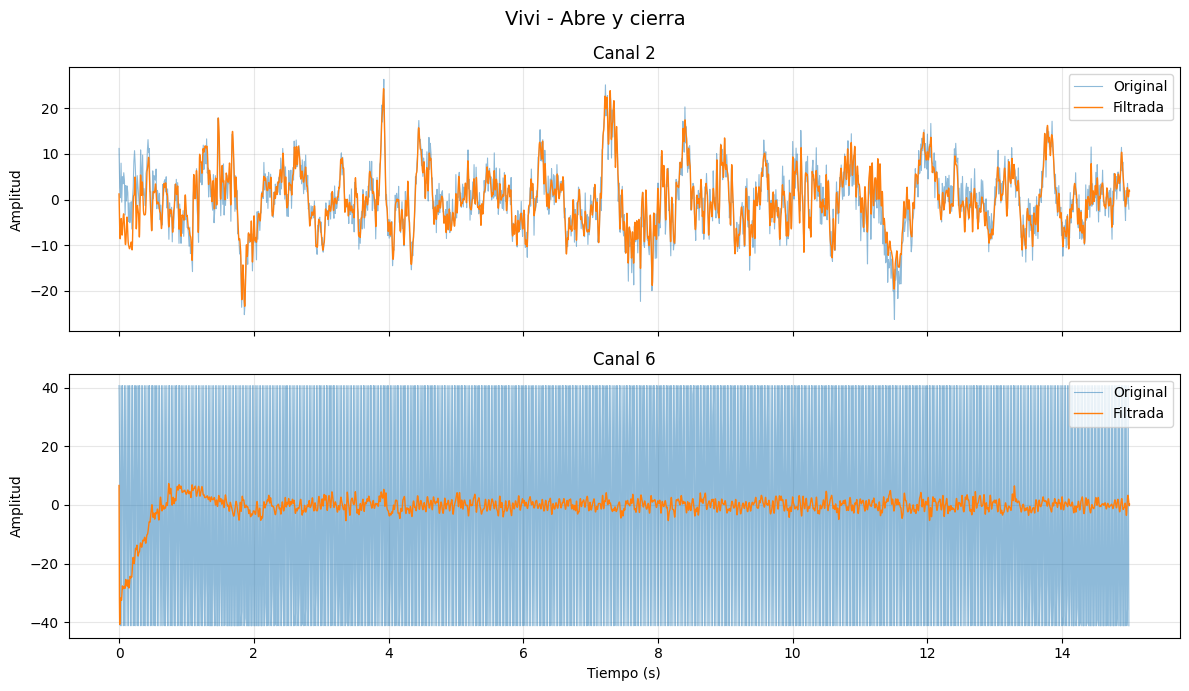

[✓] Guardado: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_Emma_Vivi/Vivi_Preguntas_complejas.png


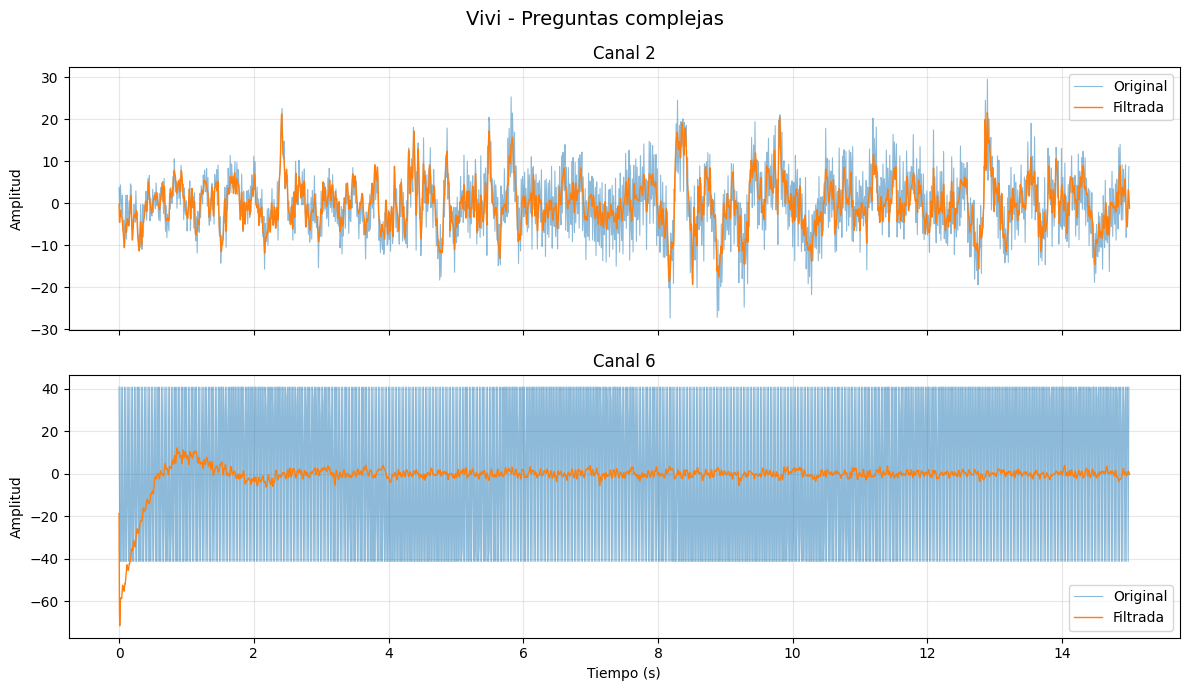

[✓] Guardado: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_Emma_Vivi/Vivi_Música_tranquila.png


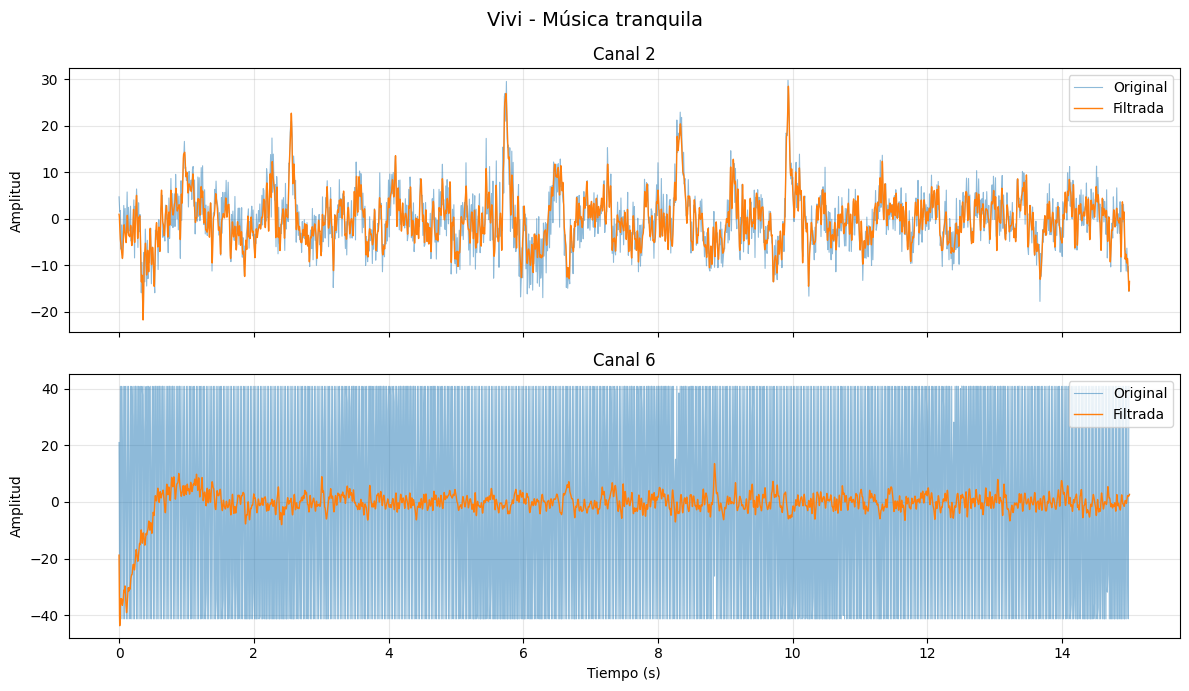

[✓] Guardado: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_Emma_Vivi/Vivi_Música_ruidosa.png


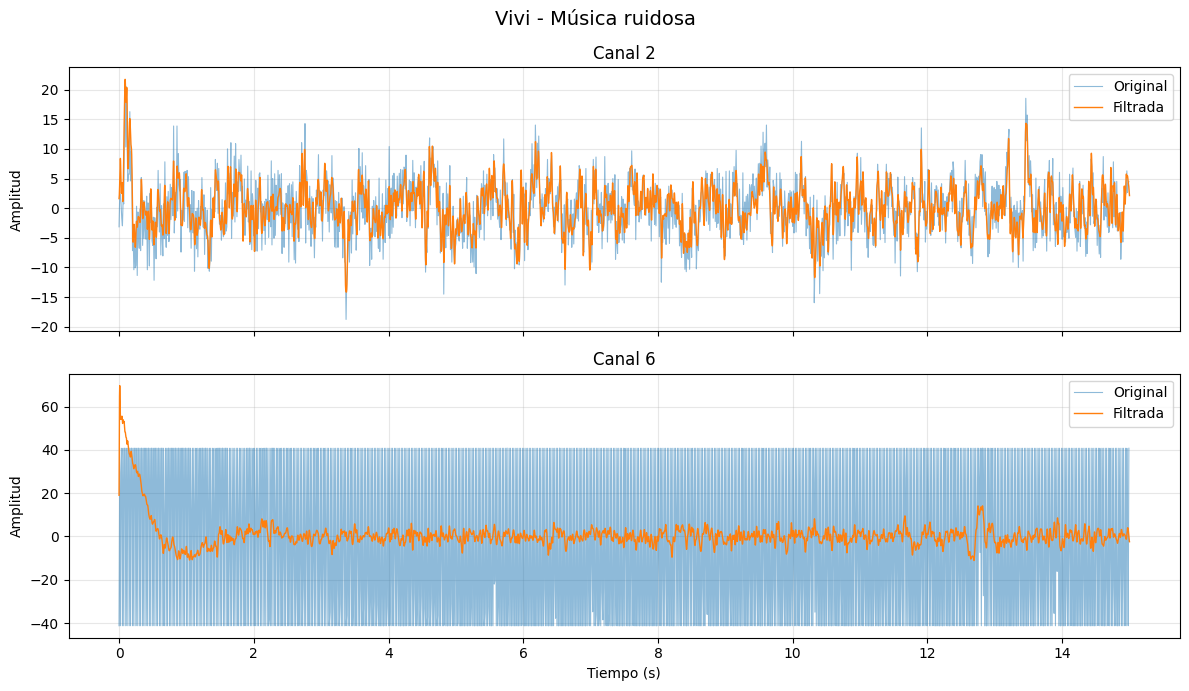

In [ ]:
# Generar las 10 gráficas individuales

for persona, condiciones in ARCHIVOS.items():
    for condicion, nombre_archivo in condiciones.items():
        fig = graficar_persona_condicion(persona, condicion, nombre_archivo)
        if fig is not None:
            plt.show()
            plt.close(fig)

## 5. Gráficas comparativas: Emma vs. Vivi

Aquí se compara a **Emma y Vivi bajo la misma condición**.

Se genera una figura por condición, con un subplot por canal. Para evitar sobrecargar la gráfica, en estas figuras se comparan las **señales filtradas** de Emma y Vivi.

Resultado: **5 figuras comparativas**.

In [ ]:
def graficar_comparacion(condicion):
    """Compara Emma vs Vivi para una condición, canal por canal."""

    fig, ejes = plt.subplots(
        len(CANALES), 1,
        figsize=(12, 7),
        squeeze=False
    )
    ejes = ejes.ravel()

    fig.suptitle(
        f"Comparación Emma vs. Vivi — {condicion}",
        fontsize=15,
        fontweight="bold"
    )

    for i, canal in enumerate(CANALES):
        ax = ejes[i]

        for persona in ["Emma", "Vivi"]:
            nombre_archivo = ARCHIVOS[persona][condicion]
            ruta = os.path.join(CARPETA_DATOS, nombre_archivo)
            resultado = cargar_senal(ruta, canal)

            if resultado is None:
                continue

            t, senal, _, fs = resultado
            senal_filtrada = filtrar_senal(senal, fs)

            ax.plot(
                t,
                senal_filtrada,
                label=persona,
                linewidth=1.0
            )

        ax.set_title(NOMBRES_CANALES.get(canal, canal))
        ax.set_xlabel("Tiempo (s)")
        ax.set_ylabel("Amplitud")
        ax.grid(alpha=0.3)
        ax.legend()

        if TIEMPO_MAX is not None:
            # Buscar la duración disponible de forma segura
            duraciones = []
            for persona in ["Emma", "Vivi"]:
                nombre_archivo = ARCHIVOS[persona][condicion]
                ruta = os.path.join(CARPETA_DATOS, nombre_archivo)
                resultado = cargar_senal(ruta, canal)
                if resultado is not None:
                    duraciones.append(resultado[0][-1])
            if duraciones:
                ax.set_xlim(0, min(TIEMPO_MAX, min(duraciones)))

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    nombre_salida = f"Comparacion_Emma_Vivi_{condicion.replace(' ', '_')}.png"
    ruta_salida = os.path.join(CARPETA_SALIDA, nombre_salida)
    fig.savefig(ruta_salida, dpi=150, bbox_inches="tight")

    print(f"✓ Guardada: {ruta_salida}")
    return fig

✓ Guardada: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_Emma_Vivi/Comparacion_Emma_Vivi_Basal.png


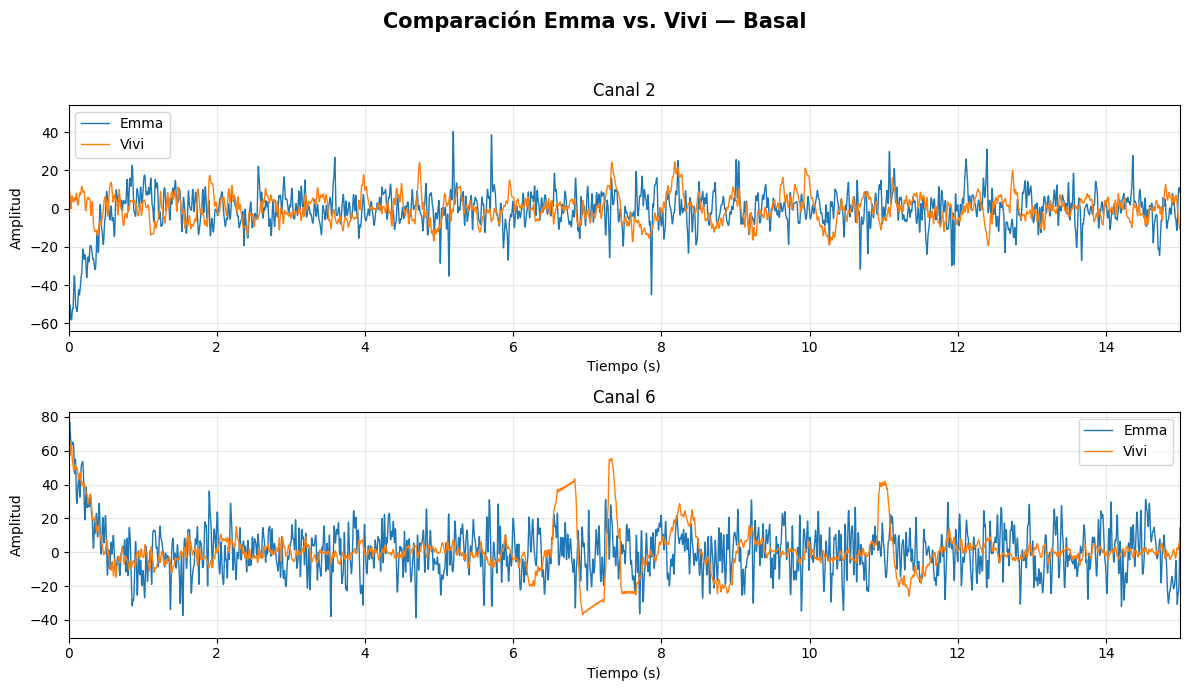

✓ Guardada: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_Emma_Vivi/Comparacion_Emma_Vivi_Abre_y_cierra.png


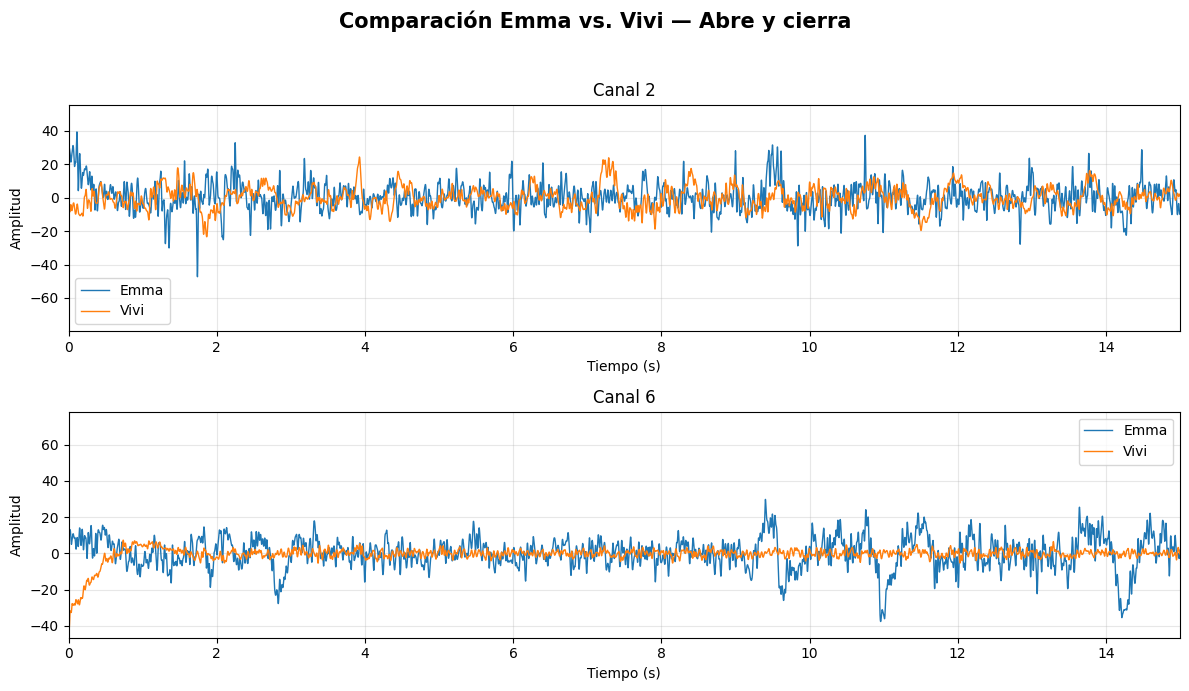

✓ Guardada: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_Emma_Vivi/Comparacion_Emma_Vivi_Preguntas_complejas.png


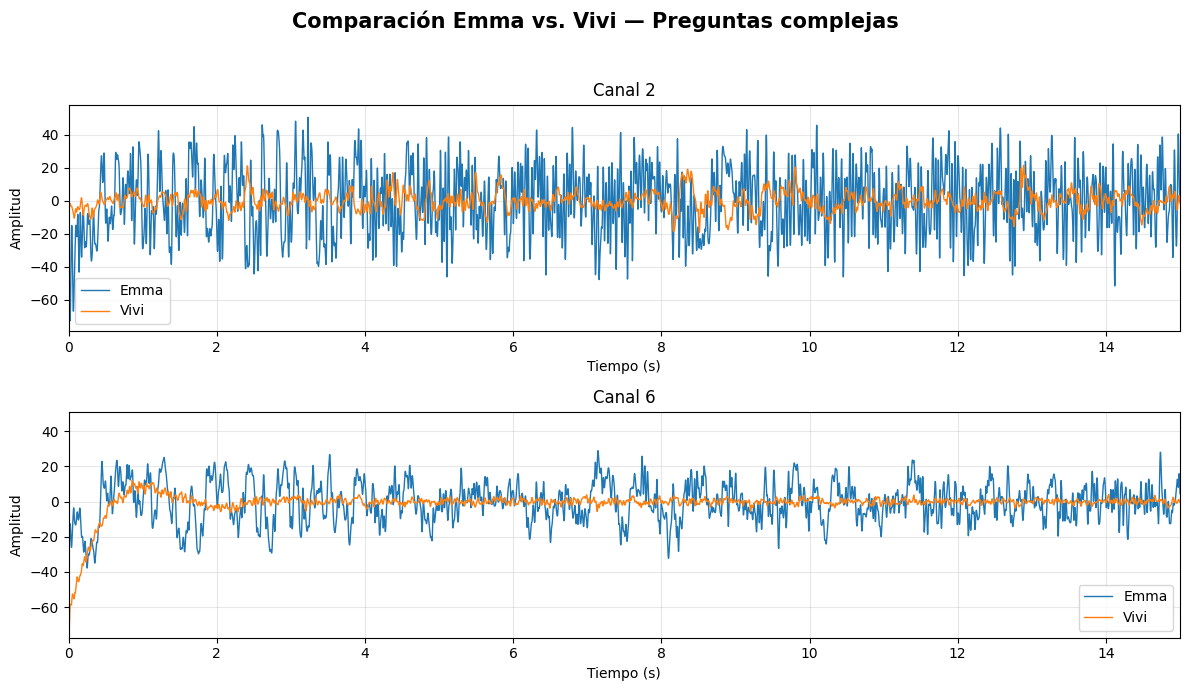

✓ Guardada: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_Emma_Vivi/Comparacion_Emma_Vivi_Música_tranquila.png


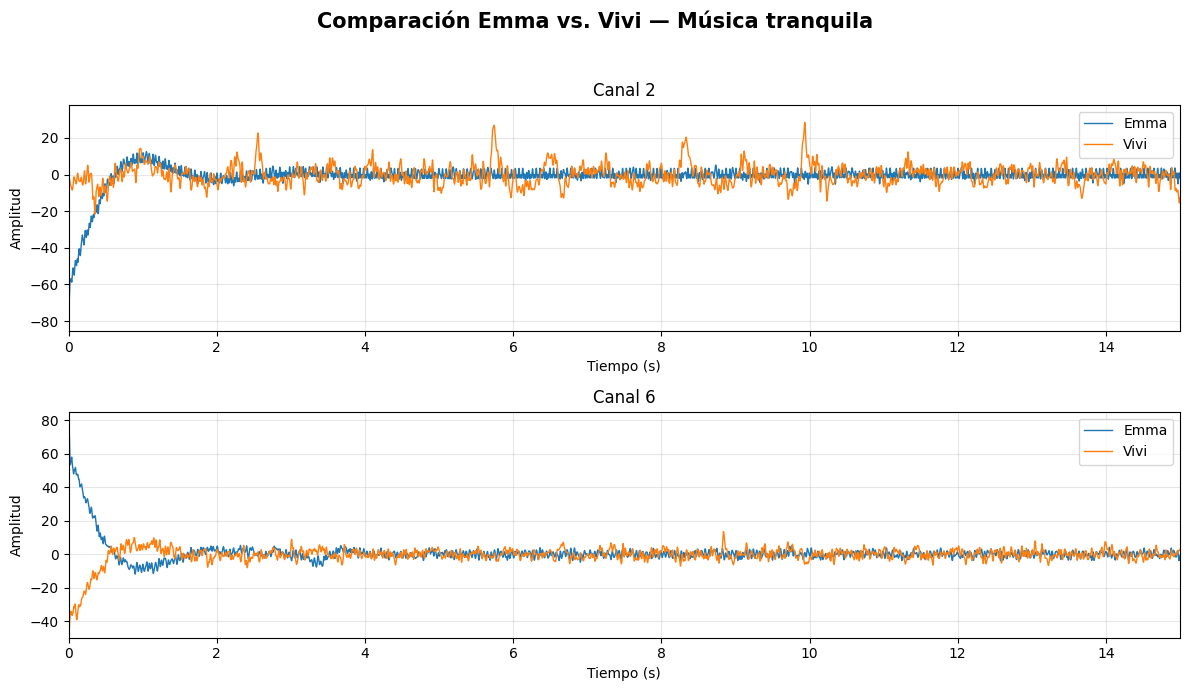

✓ Guardada: /content/drive/MyDrive/Intro Señales Biomedica (Grupo 9)/Mediciones_LAB6_EEG/figuras_Emma_Vivi/Comparacion_Emma_Vivi_Música_ruidosa.png


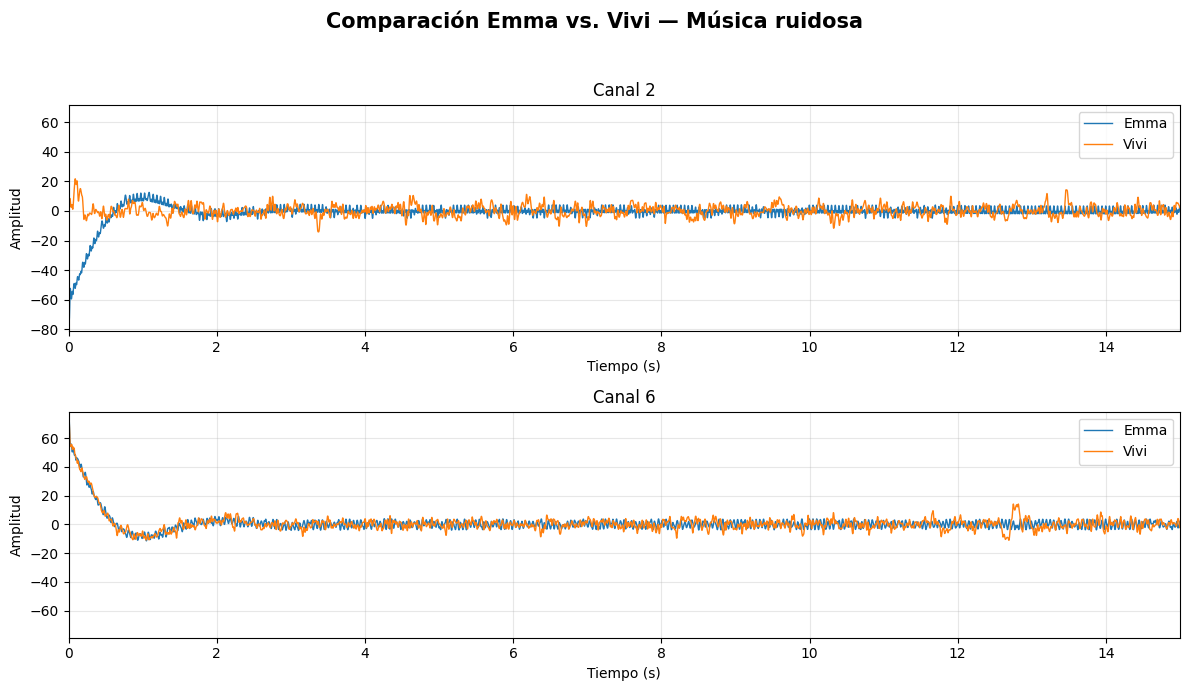

In [ ]:
# Generar las 5 gráficas comparativas

for condicion in ARCHIVOS["Emma"].keys():
    fig = graficar_comparacion(condicion)
    plt.show()
    plt.close(fig)

## 6. Resumen de las figuras generadas

| Tipo | Cantidad | Contenido |
|---|---:|---|
| Individuales | 10 | Emma/Vivi × 5 condiciones; original + filtrada en 2 canales |
| Comparativas | 5 | Emma vs. Vivi × 5 condiciones; señales filtradas en 2 canales |
| **Total** | **15** | |

Todas las figuras se guardan automáticamente en la carpeta `figuras_Emma_Vivi`.

## 7. Opcional: mostrar una sola condición con más detalle

Si después quieres revisar solo una condición, puedes ejecutar la siguiente celda cambiando `PERSONA`, `CONDICION` o `ARCHIVO`.

In [ ]:
# Ejemplo de uso individual
# fig = graficar_persona_condicion("Emma", "Basal", ARCHIVOS["Emma"]["Basal"])
# plt.show()

# Ejemplo de comparación de una sola condición
# fig = graficar_comparacion("Basal")
# plt.show()